# Model 4: BiLSTM with Attention for Swahili News Classification

Prepared by Alain  |  **Model:** `bilstm`

Recurrent models over the same tokenized input as the CNN notebook (Hochreiter and Schmidhuber, 1997; Schuster and Paliwal, 1997), with additive attention (Yang et al., 2016). All six experiments are coded in section 3f and run automatically.

| # | experiment_name | Question it answers |
|---|---|---|
| 1 | `lstm_baseline` | Plain one-direction LSTM — baseline recurrent model |
| 2 | `bilstm` | Does reading in both directions help on long articles? |
| 3 | `bilstm_attention` | Does attention help the model focus on key words? |
| 4 | `fasttext` | Do pretrained Swahili fastText vectors help? (same question as the CNN) |
| 5 | `class_weights` | Does weighting help the rare classes? |
| 6 | `uniform_attention` | Does learned attention actually matter? (Wiegreffe and Pinter, 2019) |

**On attention weights:** saved for a few articles for the error analysis, presented as an *illustration*, not as proof of why the model decided (Jain and Wallace, 2019).

**Rules for fair comparison:** train on `train`, tune on `validation`, touch `test` once at the end; log everything.

## 1. Setup

In [12]:
MEMBER = "Alain"
MODEL_NAME = "bilstm"

In [13]:
# Cloning the repository
import os
import sys
from pathlib import Path

COLAB = "google.colab" in sys.modules

if COLAB:
    !git clone https://github.com/michael-alu/nlp_language_technologies.git
    %cd nlp_language_technologies
    %pip install -q -r requirements.txt

if Path.cwd().name == "notebooks":
    os.chdir("..")

sys.path.append(os.getcwd())
print("Working directory:", os.getcwd())

Cloning into 'nlp_language_technologies'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (262/262), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 262 (delta 111), reused 226 (delta 79), pack-reused 0 (from 0)
Receiving objects: 100% (262/262), 9.70 MiB | 18.23 MiB/s, done.
Resolving deltas: 100% (111/111), done.
/content/nlp_language_technologies/nlp_language_technologies
Working directory: /content/nlp_language_technologies/nlp_language_technologies


In [14]:
# loading the dependencies
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset

from src import calibration
from src import config
from src import data_loading
from src import evaluation
from src import plots
from src.experiment_log import log_experiment
from src.reproducibility import FINAL_RUN_SEEDS, set_seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 2. Load the data

In [15]:
#Loading train, test, validation data
train = data_loading.load_train()
validation = data_loading.load_validation()
test = data_loading.load_test()
zindi_test = data_loading.load_zindi_test()

train_ids = np.asarray(data_loading.labels_to_ids(train["category"]))
validation_ids = np.asarray(data_loading.labels_to_ids(validation["category"]))
test_ids = np.asarray(data_loading.labels_to_ids(test["category"]))

print("Labels in order:", config.LABELS)
print("Sizes:",
      len(train), "for train|",
      len(validation), "for validation|",
      len(test), "for test")

Labels in order: ['kitaifa', 'michezo', 'biashara', 'kimataifa', 'burudani']
Sizes: 3603 for train| 772 for validation| 773 for test


## 3. Build and train the model

### 3a. Tokenizer and vocabulary

both models share the same tokenizer and embeddings, as required. Do not change this block in one notebook without changing it in the other.

In [16]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
MIN_FREQ = 2  # words seen once become <unk>


def tokenize(text):
    return re.findall(r"[\w']+", str(text).lower(), flags=re.UNICODE)


def build_vocabulary(texts, min_freq=MIN_FREQ):
    counts = Counter()
    for text in texts:
        counts.update(tokenize(text))
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, n in sorted(counts.items()):
        if n >= min_freq:
            vocab[word] = len(vocab)
    return vocab


def encode(text, vocab, max_len):
    ids = [vocab.get(w, vocab[UNK_TOKEN]) for w in tokenize(text)[:max_len]]
    ids += [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids


vocab = build_vocabulary(train["content"])
print("Vocabulary size:", len(vocab))

Vocabulary size: 28139


### 3b. Default settings

Experiments override these; every override is stored in the log row.

- `bidirectional`: False -> plain LSTM, True -> BiLSTM
- `attention`: `"none"` (mean pooling) | `"learned"` | `"uniform"`

In [17]:
BASE_SETTINGS = {
    "bidirectional": True,
    "attention": "learned",  # "none" | "learned" | "uniform"
    "embedding": "random",   # "random" | "fasttext"
    "class_weights": False,
    "max_len": 300, # median article is ~270 words
    "embedding_dim": 300,
    "hidden_dim": 128,
    "num_layers": 1,
    "dropout": 0.3,
    "epochs": 30,
    "batch_size": 64,
    "lr": 1e-3,
    "patience": 4, # early stopping
}

current_settings = dict(BASE_SETTINGS)

### 3c. Embedding matrix (random or pretrained fastText)

Same loader as the CNN notebook. For the fastText experiment:

In [18]:
!wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.sw.300.vec.gz
!gunzip -k cc.sw.300.vec.gz

In [19]:
FASTTEXT_PATH = "cc.sw.300.vec"
_fasttext_cache = {}


def load_fasttext_vectors(vocab, path, dim):
    if dim not in _fasttext_cache:
        raw = {}
        with open(path, encoding="utf-8", errors="ignore") as f:
            next(f)  # header line
            for line in f:
                parts = line.rstrip().split(" ")
                if len(parts[1:]) == dim:
                    raw[parts[0]] = np.asarray(parts[1:], dtype=np.float32)
        _fasttext_cache[dim] = raw
    raw = _fasttext_cache[dim]
    return {w: raw[w] for w in vocab if w in raw}


def build_embedding_matrix(vocab, settings):
    dim = settings["embedding_dim"]
    scale = 1.0 / np.sqrt(dim)
    matrix = np.random.uniform(-scale, scale, size=(len(vocab), dim)).astype(np.float32)
    matrix[vocab[PAD_TOKEN]] = 0.0
    if settings["embedding"] == "fasttext":
        pretrained = load_fasttext_vectors(vocab, FASTTEXT_PATH, dim)
        for word, vec in pretrained.items():
            matrix[vocab[word]] = vec
        print(f"fastText coverage: {len(pretrained)}/{len(vocab)} words "
              f"({100 * len(pretrained) / len(vocab):.1f}%)")
    return matrix

### 3d. Dataset and model

Embedding -> (Bi)LSTM -> pooling:
- `attention = "none"`: masked mean-pooling of the hidden states,
- `attention = "learned"`: additive attention — a small feed-forward layer scores each hidden state, softmax over non-padding positions, weighted sum (Yang et al., 2016),
- `attention = "uniform"`: same as mean-pooling but computed through the attention path, so the only difference from `"learned"` is that the weights are not learned (Wiegreffe and Pinter, 2019).

The output layer produces **logits**; `forward(..., return_attention=True)` also returns the attention weights for the error analysis.

In [20]:
class NewsDataset(Dataset):
    def __init__(self, texts, targets=None):
        self.texts = list(texts)
        self.targets = None if targets is None else np.asarray(targets)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        x = torch.tensor(encode(self.texts[i], vocab, current_settings["max_len"]),
                         dtype=torch.long)
        if self.targets is None:
            return x
        return x, torch.tensor(self.targets[i], dtype=torch.long)


class BiLSTMAttention(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_layers, num_classes,
                 dropout, bidirectional=True, attention="learned"):
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix), freeze=False, padding_idx=0
        )
        self.lstm = nn.LSTM(
            embedding_matrix.shape[1], hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.attention_layer = nn.Sequential(
            nn.Linear(out_dim, out_dim), nn.Tanh(), nn.Linear(out_dim, 1)
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, x, return_attention=False):
        mask = x != 0    # (batch, seq_len), True for real tokens
        hidden, _ = self.lstm(self.embedding(x)) # (batch, seq_len, out_dim)

        if self.attention == "learned":
            scores = self.attention_layer(hidden).squeeze(-1)
            scores = scores.masked_fill(~mask, -1e9)
            weights = torch.softmax(scores, dim=1)
        else:  # "none" (mean pool) or "uniform" (mean pool via attention path)
            lengths = mask.sum(dim=1).clamp(min=1)
            weights = mask.float() / lengths.unsqueeze(1)

        pooled = torch.bmm(weights.unsqueeze(1), hidden).squeeze(1)
        logits = self.fc(self.dropout(pooled))
        if return_attention:
            return logits, weights
        return logits


def build_model(embedding_matrix, settings):
    return BiLSTMAttention(
        embedding_matrix=embedding_matrix,
        hidden_dim=settings["hidden_dim"],
        num_layers=settings["num_layers"],
        num_classes=len(config.LABELS),
        dropout=settings["dropout"],
        bidirectional=settings["bidirectional"],
        attention=settings["attention"],
    ).to(device)

### 3e. Training loop

Same protocol as the CNN notebook, plus gradient clipping (LSTM gradients can explode). Early stopping on validation loss; per-epoch history recorded; returns validation **logits** for calibration.

In [21]:
@torch.no_grad()
def predict_logits(model, texts):
    model.eval()
    loader = DataLoader(NewsDataset(texts), batch_size=256)
    return torch.cat([model(x.to(device)) for x in loader]).cpu().numpy()


def make_criterion(settings):
    if settings["class_weights"]:
        weights = compute_class_weight(
            "balanced", classes=np.arange(len(config.LABELS)), y=train_ids
        )
        return nn.CrossEntropyLoss(
            weight=torch.tensor(weights, dtype=torch.float32, device=device))
    return nn.CrossEntropyLoss()


def train_model(settings, seed=config.RANDOM_SEED, verbose=True):
    global current_settings
    current_settings = dict(settings)
    set_seed(seed)

    embedding_matrix = build_embedding_matrix(vocab, settings)
    model = build_model(embedding_matrix, settings)
    optimizer = torch.optim.Adam(model.parameters(), lr=settings["lr"])
    criterion = make_criterion(settings)

    train_loader = DataLoader(
        NewsDataset(train["content"], train_ids),
        batch_size=settings["batch_size"], shuffle=True,
    )
    val_ds = NewsDataset(validation["content"])
    val_inputs = torch.stack([val_ds[i] for i in range(len(val_ds))]).to(device)
    val_targets = torch.tensor(validation_ids, device=device)

    history = {"train_loss": [], "validation_loss": [], "validation_macro_f1": []}
    best_state, best_val_loss, epochs_without_improvement = None, float("inf"), 0

    for epoch in range(1, settings["epochs"] + 1):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item() * len(y)

        model.eval()
        with torch.no_grad():
            val_logits = model(val_inputs)
            val_loss = criterion(val_logits, val_targets).item()
            val_macro_f1 = f1_score(validation_ids, val_logits.argmax(1).cpu(),
                                    average="macro", zero_division=0)

        history["train_loss"].append(total_loss / len(train))
        history["validation_loss"].append(val_loss)
        history["validation_macro_f1"].append(val_macro_f1)
        if verbose:
            print(f"epoch {epoch:02d} | train_loss {history['train_loss'][-1]:.4f} "
                  f"| val_loss {val_loss:.4f} | val_macro_f1 {val_macro_f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= settings["patience"]:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    validation_logits = predict_logits(model, validation["content"])
    return model, history, validation_logits

### 3f. Run all experiments

One call per experiment; each trains, calibrates, evaluates and logs (before and after temperature scaling). The fastText experiment is skipped with a warning if `cc.sw.300.vec` is missing.

Experiments 1–3 form a stepwise ablation (LSTM -> BiLSTM -> BiLSTM + attention); experiments 4–5 vary one thing on top of the full model; experiment 6 is the uniform-attention sanity check.

In [22]:
def softmax(logits):
    return torch.softmax(torch.tensor(logits), dim=1).numpy()


def run_experiment(experiment_name, overrides, notes, seed=config.RANDOM_SEED):
    settings = {**BASE_SETTINGS, **overrides}

    if settings["embedding"] == "fasttext" and not Path(FASTTEXT_PATH).exists():
        print(f"SKIP {experiment_name}: {FASTTEXT_PATH} not found (see section 3c)")
        return None

    print(f"\n=== {experiment_name} ===")
    print("overrides:", overrides)
    model, history, validation_logits = train_model(settings, seed=seed)

    #before calibration ---
    validation_probabilities = softmax(validation_logits)
    scores = evaluation.compute_scores(validation_ids, validation_probabilities)
    log_experiment(MEMBER, MODEL_NAME, experiment_name, "validation",
                   settings, scores, notes)

    # --- after temperature scaling (Guo et al., 2017) ---
    temperature = calibration.find_best_temperature(validation_logits, validation_ids)
    calibrated = calibration.softmax(validation_logits, temperature)
    cal_scores = evaluation.compute_scores(validation_ids, calibrated)
    log_experiment(MEMBER, MODEL_NAME, experiment_name + "_calibrated", "validation",
                   {**settings, "temperature": temperature}, cal_scores,
                   notes + " | after temperature scaling")

    print(f"macro-F1 {scores['macro_f1']:.4f} -> {cal_scores['macro_f1']:.4f} | "
          f"log loss {scores['log_loss']:.4f} -> {cal_scores['log_loss']:.4f} | "
          f"T={temperature:.3f}")

    return {"experiment_name": experiment_name, "settings": settings, "model": model,
            "history": history, "validation_logits": validation_logits,
            "temperature": temperature, "scores": scores, "calibrated_scores": cal_scores}


EXPERIMENTS = [
    ("lstm_baseline", {"bidirectional": False, "attention": "none"},
     "Experiment 1: plain one-direction LSTM, mean pooling, random embeddings"),
    ("bilstm", {"attention": "none"},
     "Experiment 2: bidirectional LSTM, mean pooling — does both directions help?"),
    ("bilstm_attention", {},
     "Experiment 3: BiLSTM with learned additive attention (Yang et al., 2016)"),
    ("fasttext", {"embedding": "fasttext"},
     "Experiment 4: pretrained Swahili fastText vectors (Kastanos and Martin, 2021)"),
    ("class_weights", {"class_weights": True},
     "Experiment 5: balanced class weights to help kimataifa and burudani"),
    ("uniform_attention", {"attention": "uniform"},
     "Experiment 6: attention weights replaced by uniform weights "
     "(Wiegreffe and Pinter, 2019)"),
]

experiment_results = {}
for name, overrides, notes in EXPERIMENTS:
    result = run_experiment(name, overrides, notes)
    if result is not None:
        experiment_results[name] = result


=== lstm_baseline ===
overrides: {'bidirectional': False, 'attention': 'none'}
Random seed set to 42
epoch 01 | train_loss 1.2070 | val_loss 0.8231 | val_macro_f1 0.3117
epoch 02 | train_loss 0.6569 | val_loss 0.6197 | val_macro_f1 0.3295
epoch 03 | train_loss 0.5193 | val_loss 0.4499 | val_macro_f1 0.5198
epoch 04 | train_loss 0.3246 | val_loss 0.4572 | val_macro_f1 0.5101
epoch 05 | train_loss 0.2250 | val_loss 0.4398 | val_macro_f1 0.5163
epoch 06 | train_loss 0.1645 | val_loss 0.4257 | val_macro_f1 0.5138
epoch 07 | train_loss 0.1188 | val_loss 0.4741 | val_macro_f1 0.5183
epoch 08 | train_loss 0.0948 | val_loss 0.5523 | val_macro_f1 0.5118
epoch 09 | train_loss 0.0738 | val_loss 0.6094 | val_macro_f1 0.5029
epoch 10 | train_loss 0.0677 | val_loss 0.6819 | val_macro_f1 0.4999
Early stopping at epoch 10
Logged experiment 'lstm_baseline' to /content/nlp_language_technologies/results/experiment_logs/bilstm.csv
Best temperature: 1.20 (validation log loss 0.4126)
Logged experiment 'lst

### 3g. Compare the experiments

Validation macro-F1 and log loss for every run (calibrated). we pick the final settings for section 5 from this table.

In [23]:
comparison = pd.DataFrame([
    {"experiment": name,
     "macro_f1": r["calibrated_scores"]["macro_f1"],
     "log_loss": r["calibrated_scores"]["log_loss"],
     "accuracy": r["calibrated_scores"]["accuracy"]}
    for name, r in experiment_results.items()
]).sort_values("macro_f1", ascending=False)

comparison

,experiment,macro_f1,log_loss,accuracy
2,bilstm_attention,0.5304,0.3924,0.8795
4,class_weights,0.5302,0.6724,0.7345
5,uniform_attention,0.5212,0.4040,0.8640
1,bilstm,0.5212,0.4040,0.8640
3,fasttext,0.5159,0.3956,0.8575
0,lstm_baseline,0.5138,0.4126,0.8523


## 4. Study the best experiment

We set `best_name` to the winner from the comparison table, then run the cells below for the full validation evaluation plus the attention-weight examples for the error analysis.

In [24]:
best_name = "bilstm_attention"  # changed to the winner from the table above
best = experiment_results[best_name]

calibrated_validation_probabilities = calibration.softmax(
    best["validation_logits"], best["temperature"])

evaluation.print_classification_report(validation_ids, calibrated_validation_probabilities)
best["calibrated_scores"]

              precision    recall  f1-score   support

     kitaifa       0.87      0.83      0.85       300
     michezo       0.93      0.98      0.95       258
    biashara       0.83      0.87      0.85       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.88       772
   macro avg       0.53      0.54      0.53       772
weighted avg       0.87      0.88      0.87       772



{'accuracy': 0.8795,
 'log_loss': 0.3924,
 'macro_f1': 0.5304,
 'weighted_f1': 0.8731,
 'f1_kitaifa': 0.8479,
 'f1_michezo': 0.9547,
 'f1_biashara': 0.8496,
 'f1_kimataifa': 0.0,
 'f1_burudani': 0.0}

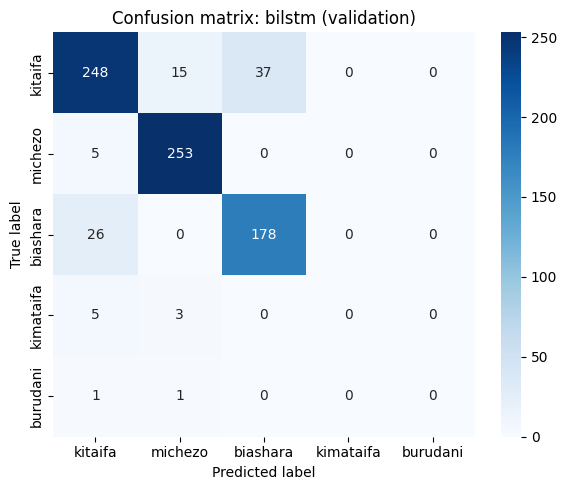

In [25]:
plots.plot_confusion_matrix(validation_ids, calibrated_validation_probabilities,
                            MODEL_NAME, "validation")

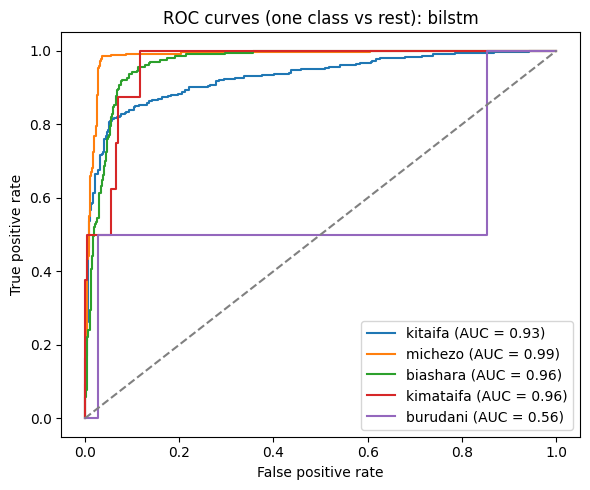

In [26]:
plots.plot_roc_curves(validation_ids, calibrated_validation_probabilities,
                      MODEL_NAME, "validation")

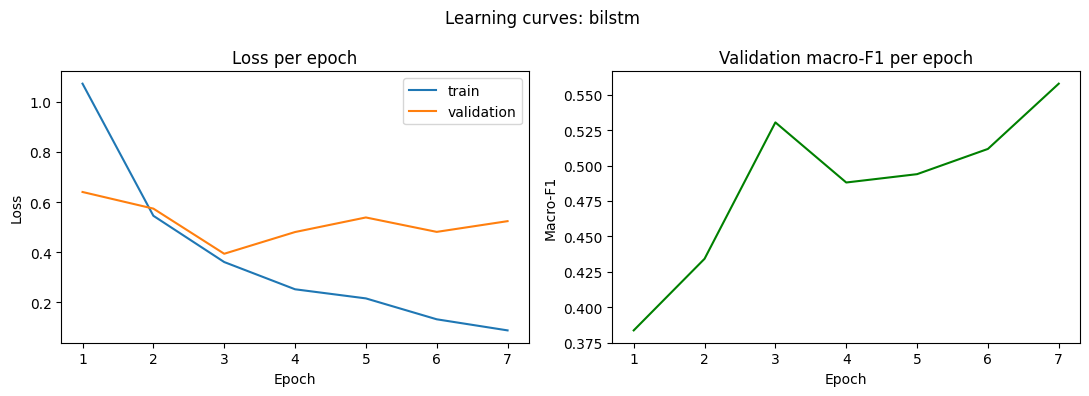

In [27]:
plots.plot_learning_curves(best["history"], MODEL_NAME)

### 4d. Attention weights for the error analysis

Save the highest-weighted tokens for a few validation articles (used in the error analysis). These are an **illustration**, not an explanation of the model's decision (Jain and Wallace, 2019). Requires `attention = "learned"`.

In [28]:
@torch.no_grad()
def attention_for_text(model, text, top_k=15):
    model.eval()
    ids = torch.tensor([encode(text, vocab, current_settings["max_len"])],
                       dtype=torch.long, device=device)
    logits, weights = model(ids, return_attention=True)
    tokens = tokenize(text)[: current_settings["max_len"]]
    w = weights[0, : len(tokens)].cpu().numpy()
    order = np.argsort(w)[::-1][:top_k]
    return pd.DataFrame({
        "token": [tokens[i] for i in order],
        "attention_weight": w[order],
        "predicted": config.LABELS[int(logits.argmax(1).item())],
    })


attention_dir = Path("results") / "figures" / MODEL_NAME
attention_dir.mkdir(parents=True, exist_ok=True)

attention_examples = []
for i in range(5):  # a few validation articles
    row = attention_for_text(best["model"], validation["content"].iloc[i])
    row["true_label"] = validation["category"].iloc[i]
    attention_examples.append(row)

attention_examples = pd.concat(attention_examples)
out_path = attention_dir / "attention_examples.csv"
attention_examples.to_csv(out_path, index=False)
print("Saved to", out_path)
attention_examples.head(15)

Saved to results/figures/bilstm/attention_examples.csv


,token,attention_weight,predicted,true_label
0,aishi,0.099021,michezo,michezo
1,beki,0.093468,michezo,michezo
2,kipa,0.083970,michezo,michezo
3,mabao,0.078898,michezo,michezo
4,stars,0.066026,michezo,michezo
5,mechi,0.064300,michezo,michezo
6,mechi,0.051763,michezo,michezo
7,ilifungwa,0.043316,michezo,michezo
8,mazoezi,0.039356,michezo,michezo
9,michuano,0.029692,michezo,michezo


## 5. Final evaluation on the test set

with the winning settings from section 4. The model is trained once per seed in `FINAL_RUN_SEEDS`; each run gets its own temperature and is logged as `final_seed_<seed>`, so the report can show the mean and spread.

In [29]:
best_settings = best["settings"]
final_runs = []

for seed in FINAL_RUN_SEEDS:
    print(f"\n=== final run, seed {seed} ===")
    final_model, final_history, val_logits = train_model(best_settings, seed=seed)

    temperature = calibration.find_best_temperature(val_logits, validation_ids)
    test_logits = predict_logits(final_model, test["content"])
    test_probabilities = calibration.softmax(test_logits, temperature)

    test_scores = evaluation.compute_scores(test_ids, test_probabilities)
    evaluation.print_classification_report(test_ids, test_probabilities)
    log_experiment(MEMBER, MODEL_NAME, f"final_seed_{seed}", "test",
                   {**best_settings, "temperature": temperature}, test_scores,
                   f"Final model ({best_name}) on the test set")
    final_runs.append({"seed": seed, "model": final_model, "history": final_history,
                       "temperature": temperature, "test_scores": test_scores,
                       "test_probabilities": test_probabilities})

summary = pd.DataFrame([
    {"seed": r["seed"],
     "macro_f1": r["test_scores"]["macro_f1"],
     "log_loss": r["test_scores"]["log_loss"],
     "accuracy": r["test_scores"]["accuracy"]}
    for r in final_runs
])
print("\nMean and std over seeds:")
print(summary[["macro_f1", "log_loss", "accuracy"]].agg(["mean", "std"]))
summary


=== final run, seed 42 ===
Random seed set to 42
epoch 01 | train_loss 1.0727 | val_loss 0.6402 | val_macro_f1 0.3837
epoch 02 | train_loss 0.5451 | val_loss 0.5738 | val_macro_f1 0.4342
epoch 03 | train_loss 0.3604 | val_loss 0.3935 | val_macro_f1 0.5304
epoch 04 | train_loss 0.2516 | val_loss 0.4802 | val_macro_f1 0.4880
epoch 05 | train_loss 0.2152 | val_loss 0.5384 | val_macro_f1 0.4939
epoch 06 | train_loss 0.1318 | val_loss 0.4808 | val_macro_f1 0.5117
epoch 07 | train_loss 0.0875 | val_loss 0.5237 | val_macro_f1 0.5578
Early stopping at epoch 7
Best temperature: 1.05 (validation log loss 0.3924)
              precision    recall  f1-score   support

     kitaifa       0.86      0.82      0.84       300
     michezo       0.94      0.96      0.95       258
    biashara       0.80      0.86      0.83       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         3

    accuracy                           0.87       773
   macro 

,seed,macro_f1,log_loss,accuracy
0,42,0.5228,0.4148,0.8668
1,7,0.5129,0.3925,0.8512
2,2026,0.5296,0.4034,0.8758


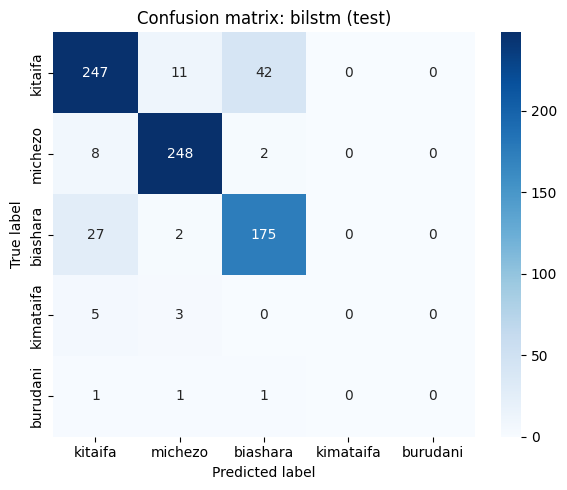

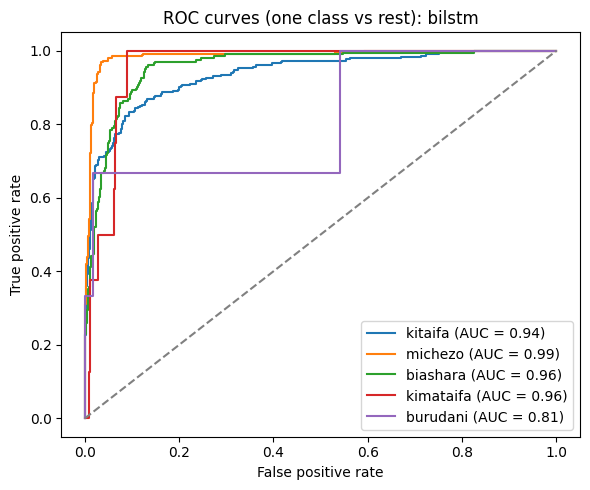

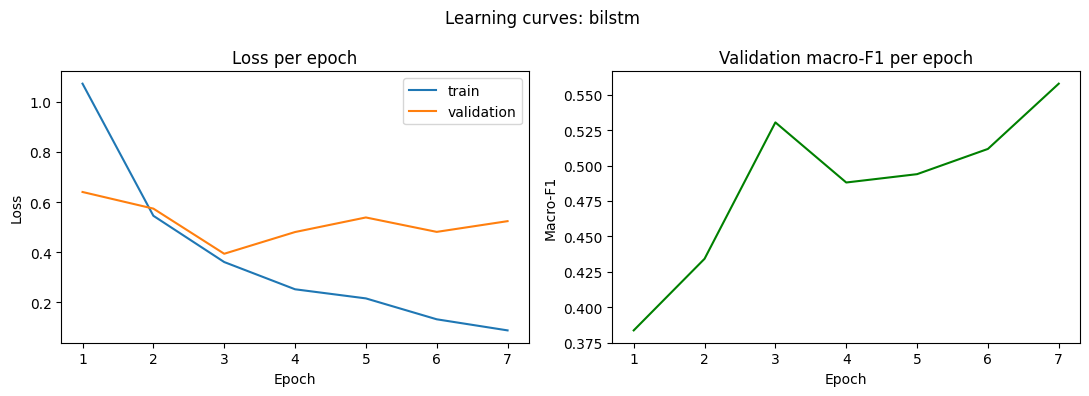

In [30]:
# figures and saved files use the median-seed run (by macro-F1) so they represent a typical run
final_runs_sorted = sorted(final_runs, key=lambda r: r["test_scores"]["macro_f1"])
typical = final_runs_sorted[len(final_runs_sorted) // 2]
final_model = typical["model"]
test_probabilities = typical["test_probabilities"]
temperature = typical["temperature"]

plots.plot_confusion_matrix(test_ids, test_probabilities, MODEL_NAME, "test")
plots.plot_roc_curves(test_ids, test_probabilities, MODEL_NAME, "test")
plots.plot_learning_curves(typical["history"], MODEL_NAME)

In [31]:
evaluation.save_misclassified_examples(test, test_ids, test_probabilities, MODEL_NAME)

Saved 103 misclassified examples to /content/nlp_language_technologies/results/misclassified/bilstm.csv


In [32]:
# attention weights for a few misclassified test articles, for the error analysis
if best_settings["attention"] == "learned":
    misclassified_rows = []
    wrong = np.where(test_ids != test_probabilities.argmax(1))[0][:5]
    for i in wrong:
        row = attention_for_text(final_model, test["content"].iloc[i])
        row["true_label"] = test["category"].iloc[i]
        misclassified_rows.append(row)

    if misclassified_rows:
        out_path = attention_dir / "attention_misclassified_test.csv"
        pd.concat(misclassified_rows).to_csv(out_path, index=False)
        print("Saved to", out_path)

Saved to results/figures/bilstm/attention_misclassified_test.csv


In [33]:
zindi_logits = predict_logits(final_model, zindi_test["content"])
zindi_probabilities = calibration.softmax(zindi_logits, temperature)

evaluation.save_zindi_submission(zindi_test, zindi_probabilities, MODEL_NAME)

Saved Zindi submission to /content/nlp_language_technologies/results/submissions/bilstm.csv


## 6. Save your results (Colab only)

Download the results to be added to the repository under `results/`.

In [34]:
if COLAB:
    from google.colab import files

    !zip -r results.zip results

    files.download("results.zip")

  adding: results/ (stored 0%)
  adding: results/submissions/ (stored 0%)
  adding: results/submissions/logistic regression.csv (deflated 48%)
  adding: results/submissions/transformer.csv (deflated 50%)
  adding: results/experiment_logs/ (stored 0%)
  adding: results/experiment_logs/logistic regression.csv (deflated 82%)
  adding: results/experiment_logs/transformer.csv (deflated 86%)
  adding: results/misclassified/ (stored 0%)
  adding: results/misclassified/logistic regression.csv (deflated 66%)
  adding: results/misclassified/transformer.csv (deflated 66%)
  adding: results/figures/ (stored 0%)
  adding: results/figures/logistic regression/ (stored 0%)
  adding: results/figures/logistic regression/confusion_matrix_validation.png (deflated 9%)
  adding: results/figures/logistic regression/confusion_matrix_test.png (deflated 9%)
  adding: results/figures/logistic regression/roc_curves_test.png (deflated 5%)
  adding: results/figures/cnn/ (stored 0%)
  adding: results/figures/cnn/con

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>